In [2]:
import numpy as np
import tools.sitnikov_integrator as sit
import matplotlib.pyplot as plt

In [3]:
e = 0.5
sit.set_eps(e)

In [30]:
# Note these formulas take into account the binaries have a = 0.5
def compute_U(t,z,v):
    return 0.5*v**2 - 1/(z**2 + sit.r(t)**2)**0.5

def compute_U_m(t,z,v):
    r_min = 0.5*(1-e)
    return 0.5*v**2 - 1/(z**2 + r_min**2)**0.5

def compute_U_M(t,z,v):
    r_max = 0.5*(1+e)
    return 0.5*v**2 - 1/(z**2 + r_max**2)**0.5

In [47]:
from scipy.integrate import solve_ivp
def sit_integrate(t0, z0, v0, T):

    ans = solve_ivp(fun = sit.phase_velocity,
                    t_span = (t0, t0 + T),
                    y0 = np.array([z0, v0]),
                    dense_output=True,
                    rtol = 1e-9,
                    atol = 1e-12)
    
    return ans.t, ans.y[0,:], ans.y[1,:]

## Example plots of U, U_m, U_M with some random initial conditions


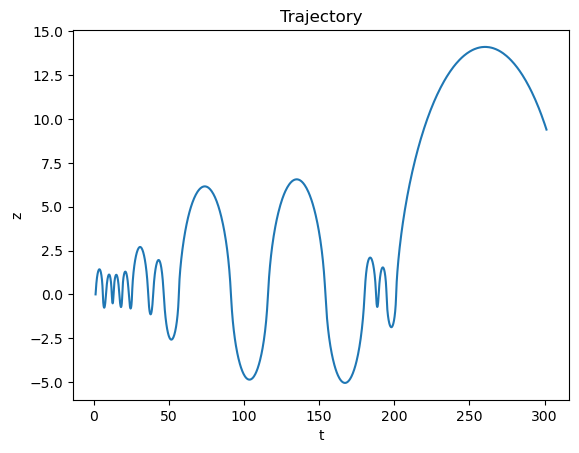

In [148]:
import random
t0 =  2*np.pi*random.random()
z0 =  0 
v0 =  1.2 + 0.2*np.random.random()
T = 300


t, z, v = sit_integrate(t0 = t0, z0 = z0, v0 = v0, T = T)

plt.plot(t,z)
plt.title("Trajectory")
plt.xlabel("t")
plt.ylabel("z")
plt.show()



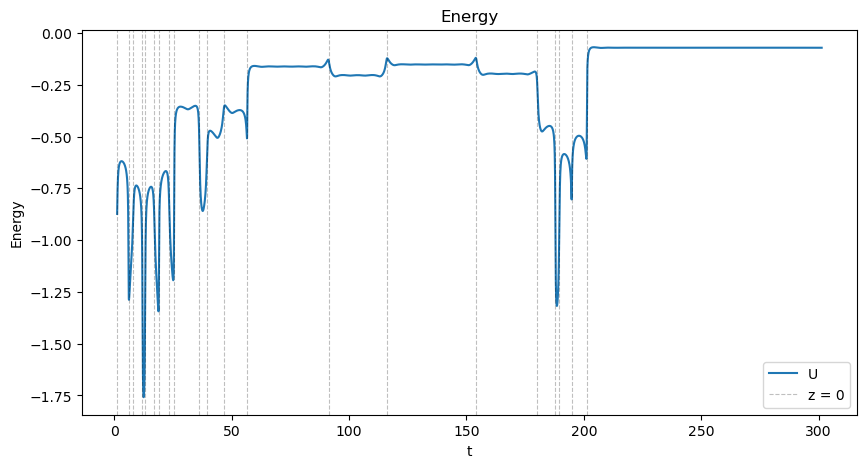

In [149]:
U = np.array([ compute_U(t[i], z[i], v[i]) for i in range(t.shape[0]) ])
U_m = np.array([ compute_U_m(t[i], z[i], v[i]) for i in range(t.shape[0])])
U_M = np.array([ compute_U_M(t[i], z[i], v[i]) for i in range(t.shape[0])])

# compute z=0 crossings (linear interpolation between samples)
zero_times = []
sign_changes = np.where(np.diff(np.sign(z)) != 0)[0]
for i in sign_changes:
    _t0, _t1 = t[i], t[i + 1]
    _z0, _z1 = z[i], z[i + 1]
    zero_times.append(_t0 - _z0 * (_t1 - _t0) / (_z1 - _z0))
zero_times = np.array(sorted(zero_times)) if zero_times else np.array([])

plt.figure(figsize = (10,5))
plt.plot(t, U, label="U")
# plt.plot(t, U_m, label="U_m")
# plt.plot(t, U_M, label="U_M")
for idx, tc in enumerate(zero_times):
    label = "z = 0" if idx == 0 else None
    plt.axvline(tc, color="k", linestyle="--", linewidth=0.8, alpha=0.25, label=label)
plt.xlabel("t")
plt.ylabel("Energy")
plt.legend()
plt.title("Energy")
plt.show()


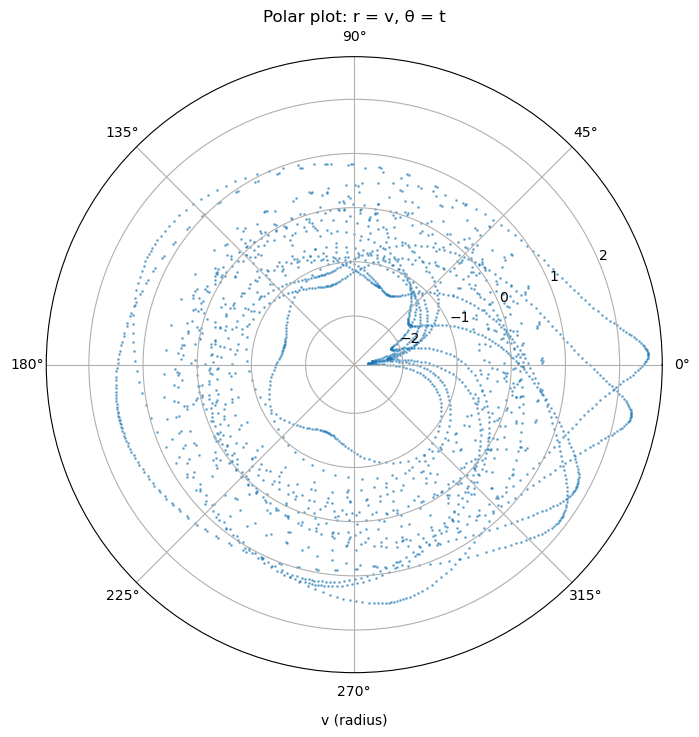

In [150]:
plt.figure(figsize=(8, 8))
ax = plt.subplot(projection='polar')
ax.scatter(t, -v, s=1, alpha=0.5)
ax.set_xlabel('v (radius)', labelpad=10)
ax.set_title('Polar plot: r = v, θ = t')
plt.show()

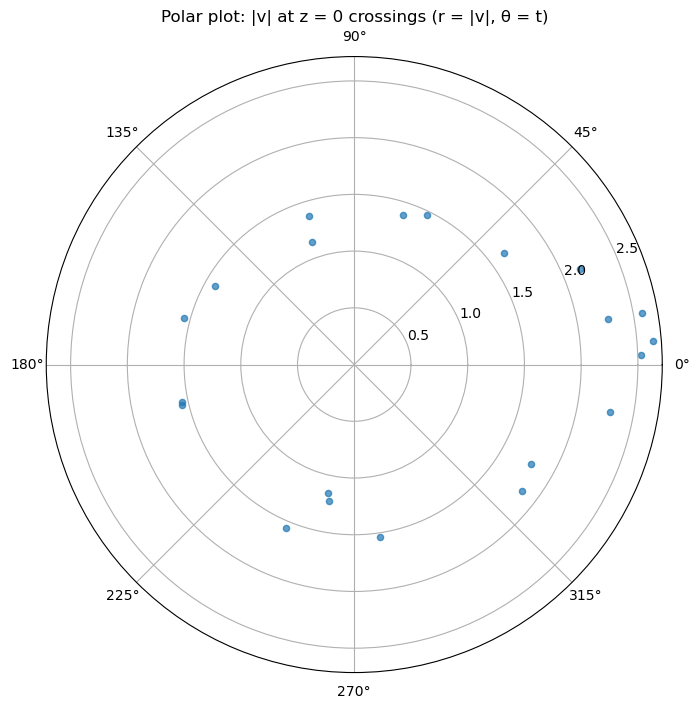

In [151]:
# Interpolate velocities at z=0 crossings
v_at_zero = np.interp(zero_times, t, v)

plt.figure(figsize=(8, 8))
ax = plt.subplot(projection='polar')
ax.scatter(zero_times, np.abs(v_at_zero), s=20, alpha=0.7)
ax.set_title('Polar plot: |v| at z = 0 crossings (r = |v|, θ = t)')
plt.show()

## What the hell? Is this a cardioid? No

If it were, I can reconstruct v = c + a*cos(t). It is not

In [138]:
v_abs = np.abs(v_at_zero)

v_min = np.min(v_abs)
v_max = np.max(v_abs)
c = 0.5*(v_min + v_max)
a = 0.5*(v_max - v_min)

cardiod_v = c + a*np.cos(zero_times)
print(c, a)

1.6032158097063371 0.5996214668556185


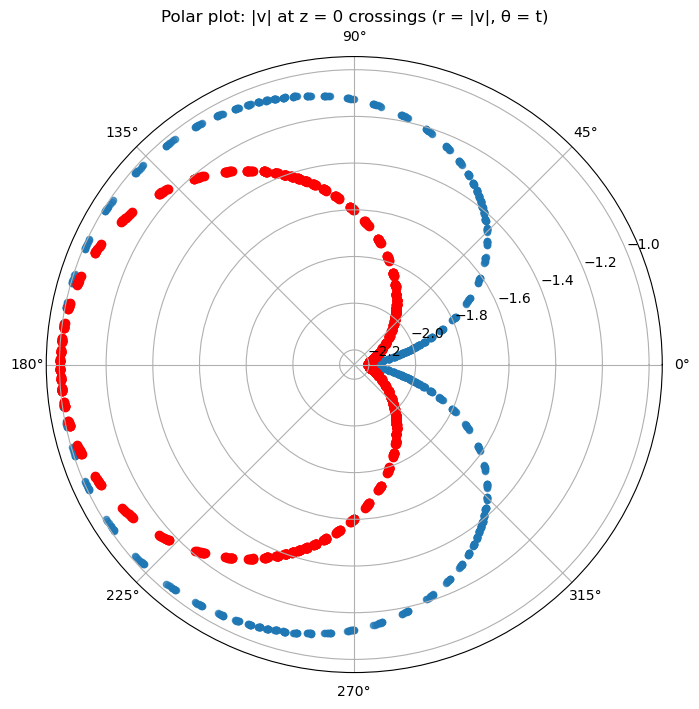

In [142]:

plt.figure(figsize=(8, 8))
ax = plt.subplot(projection='polar')
ax.scatter(zero_times, -v_abs, s=20, alpha=0.7)
ax.scatter(zero_times, -cardiod_v, color = 'red')
ax.set_title('Polar plot: |v| at z = 0 crossings (r = |v|, θ = t)')
plt.show()